# GIN — Fixed Architecture, Batch of Feature Configurations (HI-Small)

**Question:** what do manually engineered edge features add when the GNN architecture is held
**exactly fixed**? One session runs a list of configurations through literally the same code:
the `CONFIGS` list in Section 1 is the only thing you edit.

| Knob (per config) | Values | Effect |
|---|---|---|
| `mp` | `none` / `base` / `full` | edge features in message passing; `none` → `GINConv`, else `GINEConv(edge_dim)` |
| `readout` | `base` / `full` / `gfp` | edge features concatenated at the classifier `[h_src, h_dst, e_seed]` |

Fixed for every run (Altman et al. 2023): 2 GIN layers, hidden 128, dropout 0.3, neighbour
sampling `[100, 100]`, `BCEWithLogits(pos_weight=8)`, Adam 1e-3 + cosine, 20 epochs, threshold
chosen on validation, best-val-F1 checkpoint, test scored once. Every run prints and stores the
**architecture-invariant parameter count (67,587)** — it must match across all feature configs.

Per-epoch overfitting diagnostics: train & validation loss (same weighted BCE), F1 (train reuses
the validation threshold), PR-AUC. Each run saves `results.json`, `history.csv`, `best.pt`,
`curves.png` under `outputs/<run_name>/`; a summary table compares all runs at the end.

## 0. Environment (Kaggle)

`LinkNeighborLoader` needs `pyg_lib` (or `torch_sparse`). Adjust the wheel URL to the torch /
CUDA version printed in the first line, then **restart the session** after installing.

In [1]:
# import torch
# print('torch', torch.__version__, '| cuda', torch.version.cuda)

# # wheel index must match the torch + CUDA version printed above
# !pip install -q torch_geometric
# !pip install -q pyg_lib torch_scatter torch_sparse -f https://data.pyg.org/whl/torch-2.8.0+cu126.html

In [2]:
!pip uninstall -y torch torchvision torchaudio torch-scatter torch-sparse pyg_lib
!pip install torch==2.8.0 torchvision torchaudio --index-url https://download.pytorch.org/whl/cu126
!pip install torch-scatter torch-sparse torch-cluster -f https://data.pyg.org/whl/torch-2.8.0+cu126.html
!pip install torch_geometric

Found existing installation: torch 2.10.0+cu128
Uninstalling torch-2.10.0+cu128:
  Successfully uninstalled torch-2.10.0+cu128
Found existing installation: torchvision 0.25.0+cu128
Uninstalling torchvision-0.25.0+cu128:
  Successfully uninstalled torchvision-0.25.0+cu128
Found existing installation: torchaudio 2.10.0+cu128
Uninstalling torchaudio-2.10.0+cu128:
  Successfully uninstalled torchaudio-2.10.0+cu128
Looking in indexes: https://download.pytorch.org/whl/cu126
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.7/23.7 MB 146.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 897.7/897.7 kB 228.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 134.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 393.1/393.1 MB 86.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 200.2/200.2 MB 106.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 173.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

## 1. Imports & configuration

In [3]:
import gc
import json
import os
import random
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import psutil
import torch
import torch.nn as nn
from sklearn.metrics import (average_precision_score, f1_score, precision_recall_curve,
                             precision_score, recall_score, roc_auc_score)
from torch_geometric.data import Data
from torch_geometric.loader import LinkNeighborLoader
from torch_geometric.nn import GINConv, GINEConv
from tqdm.auto import tqdm

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'torch {torch.__version__} | device {device}')

torch 2.8.0+cu126 | device cuda


In [4]:
# ---------------- experiment configurations to run in THIS session ----------------
# Each entry is one experiment. Everything else below is FIXED and shared by all runs.
#   mp      : edge features in message passing   'none' | 'base' | 'full'
#   readout : edge features at the classifier    'base' | 'full' | 'gfp'
CONFIGS = [
    dict(mp='none', readout='base'),   # Run 1  — GIN,  baseline features
    dict(mp='base', readout='base'),   # Run 2  — GINE, baseline features
    dict(mp='none', readout='full'),   # Run 7  — GIN,  +GFP at the readout
    dict(mp='base', readout='full'),   # Run 16 — GINE, GFP at the readout only (isolates WHERE the GFP uplift comes from)
    dict(mp='full', readout='full'),   # Run 8  — GINE, +GFP everywhere
]

MP_DIRECTION      = 'in'     # 'in' | 'bidirectional' — held fixed for the whole batch
TEMPORAL_SAMPLING = False    # True samples only edges earlier than the seed (needs recent pyg-lib)

# ---------------- fixed recipe (identical for every run) ----------------
HIDDEN        = 128
NUM_LAYERS    = 2
DROPOUT       = 0.3
NUM_NEIGHBORS = [100, 100]     # neighbours sampled per hop (one entry per GNN layer)
BATCH_SIZE    = 8192           # seed edges per mini-batch
EPOCHS        = 20
LR            = 1e-3
WEIGHT_DECAY  = 1e-5
POS_WEIGHT    = 8.0            # weight of the laundering class in the loss
SEED          = 42

# ---------------- paths ----------------
DATA_DIR = '/kaggle/input/datasets/sandrokhizanishvili/hi-small-gnn'
OUT_ROOT = '/kaggle/working/outputs'

## 2. Load graphs and feature column groups

`feature_meta.json` says which `edge_attr` columns are baseline (first 20) and GFP (next 61).
Each configuration picks its column lists from `COL_SETS`; node features `x` are always used.

In [5]:
train_graph = torch.load(f'{DATA_DIR}/train_graph.pt', weights_only=False)
val_graph   = torch.load(f'{DATA_DIR}/val_graph.pt',   weights_only=False)
test_graph  = torch.load(f'{DATA_DIR}/test_graph.pt',  weights_only=False)
meta = json.load(open(f'{DATA_DIR}/feature_meta.json'))

all_cols = meta['EDGE_FEAT_COLS']
base_idx = [all_cols.index(c) for c in meta['BASE_EDGE_COLS']]   # 0..19
gfp_idx  = [all_cols.index(c) for c in meta['GFP_FEAT_COLS']]    # 20..80
COL_SETS = {'none': [], 'base': base_idx, 'gfp': gfp_idx, 'full': base_idx + gfp_idx}
NODE_DIM = train_graph.x.shape[1]

for name, g in [('train', train_graph), ('val', val_graph), ('test', test_graph)]:
    n_eval = int(g.eval_mask.sum())
    n_pos  = int((g.y[g.eval_mask] == 1).sum())
    print(f'{name:<5} nodes={g.num_nodes:,} edges={g.edge_index.shape[1]:,} '
          f'evaluated={n_eval:,} laundering={n_pos:,} ({n_pos / n_eval:.4%})')

train nodes=515,070 edges=3,046,342 evaluated=3,046,342 laundering=2,297 (0.0754%)
val   nodes=515,070 edges=4,061,789 evaluated=1,015,447 laundering=1,082 (0.1066%)
test  nodes=515,070 edges=5,077,237 evaluated=1,015,448 laundering=1,143 (0.1126%)


## 3. Model — one class for every configuration

- `node_proj`: `Linear(node_dim → 128)`
- `NUM_LAYERS` × GIN layer. Each conv uses the **same** node MLP `Linear(128,128) → BatchNorm → ReLU → Linear(128,128)` with learnable ε. `mp_edge_dim = 0` → `GINConv`, otherwise `GINEConv(edge_dim)` (adds only a `Linear(edge_dim → 128)` on the edge term). `bidirectional` adds a second conv over reversed edges, merged with `Linear(256 → 128)`. Then ReLU, dropout, and the residual connection `h = h + layer(h)`.
- `classifier`: MLP on `[h_src, h_dst, edge feats]` — hidden 128, one logit.

```text
             node features x  [N x 6]
                      |
             Linear 6->128 . ReLU
                      |
        +-------------v-------------+
        | GIN layer 1               |<-- MP edge features e_uv {0|20|81}
        |  m_u = h_u (+ W_e.e_uv)   |    (absent when MP = 'none' -> GINConv;
        |  (1+eps).h_v + sum m_u    |     bidirectional adds a 2nd conv over
        |  MLP: 128->128.BN.ReLU.   |     reversed edges, concat -> 256->128)
        |       128->128            |
        |  ReLU . Dropout . +resid  |
        +-------------+-------------+
        +-------------v-------------+
        | GIN layer 2 (same form)   |<-- e_uv
        +-------------+-------------+
                      |
             embeddings h  [N x 128]
              +-------+-------+
              |               |
          h_s [128]       h_t [128]     seed edge features e_seed {20|81|61}
              |               |             | (raw values, skip MP)
              +-------+-------+             |
                      v                     |
        concat [ h_s || h_t || e_seed ] <---+     width: 128+128+d_seed
                      |
        Linear(256+d_seed -> 128) . ReLU . Dropout . Linear 128->1
                      |
             sigmoid -> P(laundering)
```
Amber rule of the experiment: only `e_uv` width, `e_seed` width (and hence the two input
projections) change between configurations — every other weight shape is identical.

In [6]:
def gin_mlp(hidden):
    '''The MLP "phi" applied after aggregation in every GIN layer.

    Identical in all configurations: Linear 128->128 . BatchNorm . ReLU . Linear 128->128.
    GIN theory needs at least one hidden layer here to keep WL expressiveness;
    BatchNorm tames sum-aggregated activations of hub accounts (degree up to 168k).
    '''
    return nn.Sequential(nn.Linear(hidden, hidden), nn.BatchNorm1d(hidden), nn.ReLU(),
                         nn.Linear(hidden, hidden))


def make_conv(hidden, mp_edge_dim):
    '''One graph convolution; this choice is the ONLY difference between configs.

    mp_edge_dim = 0  -> GINConv : message u->v is  h_u
    mp_edge_dim > 0  -> GINEConv: message u->v is  ReLU(h_u + W_e @ e_uv),
                        with W_e: [hidden, mp_edge_dim] the only extra weight.
    train_eps=True makes eps in (1+eps)*h_v learnable (self vs neighbourhood weight).
    '''
    if mp_edge_dim > 0:
        return GINEConv(gin_mlp(hidden), train_eps=True, edge_dim=mp_edge_dim)
    return GINConv(gin_mlp(hidden), train_eps=True)


class GINLayer(nn.Module):
    '''One message-passing step, optionally in both directions, with a residual.

    Update:   h_v <- h_v + Dropout(ReLU( conv(h, edges) ))
    Conv:     phi( (1+eps)*h_v + sum of messages from neighbours )

    edge_index rows are [senders; receivers] and messages flow sender -> receiver,
    so conv_in makes each account aggregate the accounts that PAID it. With
    bidirectional=True a second conv runs on flipped edges ("whom I paid") and
    the two 128-dim views are merged back to 128.

    Args:
        hidden        (int)  : embedding width (128)
        mp_edge_dim   (int)  : edge feature width in message passing (0 | 20 | 81)
        bidirectional (bool) : add the reverse-direction conv
        dropout       (float): dropout rate after the conv (0.3)
    '''

    def __init__(self, hidden, mp_edge_dim, bidirectional, dropout):
        super().__init__()
        self.use_edges = mp_edge_dim > 0
        self.bidirectional = bidirectional
        self.conv_in = make_conv(hidden, mp_edge_dim)          # "who paid me"
        if bidirectional:
            self.conv_out = make_conv(hidden, mp_edge_dim)     # "whom I paid"
            self.merge = nn.Linear(2 * hidden, hidden)         # concat 128||128 -> 128
        self.dropout = nn.Dropout(dropout)

    def apply_conv(self, conv, h, edge_index, edge_attr):
        '''Route the call: GINEConv takes edge features, GINConv takes none.'''
        if self.use_edges:
            return conv(h, edge_index, edge_attr)
        return conv(h, edge_index)

    def forward(self, h, edge_index, edge_attr):
        '''h: [N, 128] in -> [N, 128] out (refined through the residual).'''
        out = self.apply_conv(self.conv_in, h, edge_index, edge_attr)
        if self.bidirectional:
            # flip(0) swaps senders<->receivers = reversed edges; same edge_attr,
            # a transaction's features describe it in both directions.
            out_rev = self.apply_conv(self.conv_out, h, edge_index.flip(0), edge_attr)
            out = self.merge(torch.cat([out, out_rev], dim=1))
        return h + self.dropout(torch.relu(out))   # residual: refine, don't replace


class GIN(nn.Module):
    '''GIN edge classifier with a fixed architecture.

    Args:
        node_dim         (int)  : raw node feature width (6, entity one-hot)
        mp_edge_dim      (int)  : edge features in message passing (0 | 20 | 81)
        readout_edge_dim (int)  : edge features at the classifier (20 | 81 | 61)
        bidirectional    (bool) : incoming-only vs both-directions aggregation

    Parameter shapes (what "fixed architecture" means concretely):
        node_proj              : [128, node_dim] + [128]
        per layer  - conv MLP  : [128,128]+[128] . BN [128]+[128] . [128,128]+[128], eps scalar
        per layer  - GINE only : W_e [128, mp_edge_dim] + [128]
        per layer  - bidi only : second conv (same shapes) + merge [128, 256] + [128]
        classifier             : [128, 256 + readout_edge_dim] + [128], then [1, 128] + [1]
    Only W_e and the classifier's first layer may change with the feature set.
    '''

    def __init__(self, node_dim, mp_edge_dim, readout_edge_dim, bidirectional):
        super().__init__()
        # embed the 6 entity-type bits into the shared 128-dim working space
        self.node_proj = nn.Linear(node_dim, HIDDEN)
        # NUM_LAYERS (=2) layers of identical structure, each with its own weights
        self.layers = nn.ModuleList(
            [GINLayer(HIDDEN, mp_edge_dim, bidirectional, DROPOUT) for _ in range(NUM_LAYERS)])
        # readout MLP on [h_src || h_dst || raw seed edge features] -> one logit
        self.classifier = nn.Sequential(
            nn.Linear(2 * HIDDEN + readout_edge_dim, HIDDEN), nn.ReLU(), nn.Dropout(DROPOUT),
            nn.Linear(HIDDEN, 1))

    def forward(self, x, edge_index, edge_attr, seed_index, seed_edge_feats):
        '''Score a batch of seed transactions.

        Args (all batch-local, produced by LinkNeighborLoader):
            x               [N, 6]       node features of the sampled subgraph
            edge_index      [2, E]       sampled edges (context + seeds)
            edge_attr       [E, mp_dim]  MP edge features, or None when MP = 'none'
            seed_index      [2, B]       endpoint ids of the B seed transactions
            seed_edge_feats [B, ro_dim]  raw readout features of the seed transactions

        Returns:
            [B] raw logits — BCEWithLogitsLoss / torch.sigmoid apply the sigmoid.
        '''
        # 1) node embeddings by message passing: [N, 6] -> [N, 128], 2 hops of context
        h = torch.relu(self.node_proj(x))
        for layer in self.layers:
            h = layer(h, edge_index, edge_attr)
        # 2) classify each seed s->t from its endpoints + its own raw features
        z = torch.cat([h[seed_index[0]], h[seed_index[1]], seed_edge_feats], dim=1)
        return self.classifier(z).squeeze(-1)      # [B, 1] -> [B]


## 4. Shared helpers — loader, prediction, metrics

Everything is parameterized by the config's column lists, so every configuration runs through
literally the same code. Seed edges' readout features are looked up via `batch.input_id`.

**Memory:** loaders are built **once per run** and reused by all epochs. Rebuilding them every
epoch (as an earlier version did) re-copied the selected edge-feature columns (~1 GB each for
the `full` set) and rebuilt the sampler's CSC graph 3× per epoch — the resulting RAM churn
eventually killed the Kaggle kernel mid-batch.

In [7]:
def make_loader(g, shuffle, mp_idx, readout_idx):
    '''Neighbour-sampling loader + per-seed readout features for one split.

    Called ONCE per run per split; the loader is then reused by every epoch
    (a shuffled loader reshuffles itself on each iteration automatically).
    '''
    # graph used for message passing: node features + (optionally) the MP edge columns
    if len(mp_idx) > 0:
        mp_edge_attr = g.edge_attr[:, mp_idx]
    else:
        mp_edge_attr = None
    mp_graph = Data(x=g.x, edge_index=g.edge_index, edge_attr=mp_edge_attr,
                    edge_time=g.edge_time, num_nodes=g.num_nodes)

    # seed edges = the evaluated edges of this split
    seed_mask  = g.eval_mask
    seed_index = g.edge_index[:, seed_mask]
    seed_y     = g.y[seed_mask].float()
    seed_feats = g.edge_attr[seed_mask][:, readout_idx]      # readout features per seed edge

    if TEMPORAL_SAMPLING:
        loader = LinkNeighborLoader(mp_graph, num_neighbors=NUM_NEIGHBORS, batch_size=BATCH_SIZE,
                                    edge_label_index=seed_index, edge_label=seed_y, shuffle=shuffle,
                                    time_attr='edge_time', edge_label_time=g.edge_time[seed_mask])
    else:
        loader = LinkNeighborLoader(mp_graph, num_neighbors=NUM_NEIGHBORS, batch_size=BATCH_SIZE,
                                    edge_label_index=seed_index, edge_label=seed_y, shuffle=shuffle)
    return loader, seed_feats


def forward_batch(model, batch, seed_feats):
    # batch.input_id = positions of this batch's seed edges in the seed list
    batch = batch.to(device)
    feats = seed_feats[batch.input_id.cpu()].to(device)
    logits = model(batch.x, batch.edge_index, batch.edge_attr, batch.edge_label_index, feats)
    return logits, batch.edge_label


@torch.no_grad()
def predict(model, loader, seed_feats, name):
    '''True labels and predicted probabilities for all seed edges served by `loader`.

    Also fine with a shuffled loader (train diagnostics): labels and probabilities
    are collected pairwise, and no metric depends on the row order.
    '''
    model.eval()
    labels, probs = [], []
    for batch in tqdm(loader, desc=f'predict {name}', leave=False):
        logits, y = forward_batch(model, batch, seed_feats)
        probs.append(torch.sigmoid(logits).cpu().numpy())
        labels.append(y.cpu().numpy())
    return np.concatenate(labels).astype(int), np.concatenate(probs)


def best_f1_threshold(y, p):
    # threshold that maximises F1 on the given (validation) predictions
    precision, recall, thresholds = precision_recall_curve(y, p)
    f1 = 2 * precision[:-1] * recall[:-1] / (precision[:-1] + recall[:-1] + 1e-12)
    return float(thresholds[f1.argmax()]), float(f1.max())


def weighted_bce(y, p):
    # the training objective computed from eval-mode predictions, so the
    # train and validation loss curves are directly comparable
    p = np.clip(p, 1e-7, 1 - 1e-7)
    return float(-np.mean(POS_WEIGHT * y * np.log(p) + (1 - y) * np.log(1 - p)))


def compute_metrics(y, p, threshold):
    pred = (p >= threshold).astype(int)
    return {
        'f1':        f1_score(y, pred),
        'precision': precision_score(y, pred, zero_division=0),
        'recall':    recall_score(y, pred),
        'pr_auc':    average_precision_score(y, p),
        'roc_auc':   roc_auc_score(y, p),
        'threshold': threshold,
    }

## 5. One experiment = one function call

`run_experiment(mp, readout)` builds a fresh model, trains it with the shared recipe, keeps the
best-validation-F1 checkpoint, scores all three splits at the validation-chosen threshold, saves
everything under `outputs/<run_name>/`, and returns a summary row.

In [8]:
def run_experiment(mp, readout):
    '''Train and evaluate one feature configuration; returns a summary dict.'''
    run_name = f'gin_mp-{mp}_readout-{readout}_dir-{MP_DIRECTION}'
    if TEMPORAL_SAMPLING:
        run_name = run_name + '_temporal'
    out_dir = f'{OUT_ROOT}/{run_name}'
    os.makedirs(out_dir, exist_ok=True)
    mp_idx, readout_idx = COL_SETS[mp], COL_SETS[readout]

    # same seed for every run -> identical init of the shared (invariant) weights
    random.seed(SEED)
    np.random.seed(SEED)
    torch.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)

    model = GIN(NODE_DIM, len(mp_idx), len(readout_idx), MP_DIRECTION == 'bidirectional').to(device)
    n_params = sum(p.numel() for p in model.parameters())
    width_dependent = 0
    for pname, p in model.named_parameters():
        if '.lin.' in pname or pname.startswith('classifier.0.'):
            width_dependent += p.numel()
    invariant_params = n_params - width_dependent

    print(f'=== {run_name} ===')
    print(f'MP edge features: {len(mp_idx)} | readout edge features: {len(readout_idx)}')
    print(f'total params: {n_params:,} | architecture-invariant: {invariant_params:,}')

    # one loader per split for the WHOLE run — rebuilding these every epoch
    # copies GBs of edge features each time and eventually exhausts RAM
    train_loader, train_feats = make_loader(train_graph, shuffle=True,
                                            mp_idx=mp_idx, readout_idx=readout_idx)
    val_loader,   val_feats   = make_loader(val_graph,   shuffle=False,
                                            mp_idx=mp_idx, readout_idx=readout_idx)
    test_loader,  test_feats  = make_loader(test_graph,  shuffle=False,
                                            mp_idx=mp_idx, readout_idx=readout_idx)

    criterion = nn.BCEWithLogitsLoss(pos_weight=torch.tensor([POS_WEIGHT], device=device))
    optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

    history = []
    best_val_f1, best_epoch, best_threshold = -1.0, 0, 0.5

    for epoch in range(1, EPOCHS + 1):
        t0 = time.time()

        # ---- one training pass ----
        model.train()
        for batch in tqdm(train_loader, desc='train', leave=False):
            optimizer.zero_grad()
            logits, y = forward_batch(model, batch, train_feats)
            loss = criterion(logits, y)
            loss.backward()
            optimizer.step()

        # ---- score train and validation in eval mode (overfitting diagnostics) ----
        y_train, p_train = predict(model, train_loader, train_feats, 'train')
        y_val,   p_val   = predict(model, val_loader,   val_feats,   'val')

        # threshold is always chosen on validation; train F1 reuses it
        threshold, val_f1 = best_f1_threshold(y_val, p_val)
        train_f1 = f1_score(y_train, (p_train >= threshold).astype(int))

        # checkpoint criterion: best validation F1 so far
        is_best = val_f1 > best_val_f1
        if is_best:
            best_val_f1, best_epoch, best_threshold = val_f1, epoch, threshold
            torch.save(model.state_dict(), f'{out_dir}/best.pt')

        history.append({
            'epoch':        epoch,
            'train_loss':   weighted_bce(y_train, p_train),
            'val_loss':     weighted_bce(y_val, p_val),
            'train_f1':     train_f1,
            'val_f1':       val_f1,
            'train_pr_auc': average_precision_score(y_train, p_train),
            'val_pr_auc':   average_precision_score(y_val, p_val),
            'val_roc_auc':  roc_auc_score(y_val, p_val),
            'threshold':    threshold,
            'seconds':      time.time() - t0,
        })
        r = history[-1]
        ram_gb = psutil.Process().memory_info().rss / 2**30   # watch for RAM creep
        print(f"epoch {epoch:02d} | loss {r['train_loss']:.4f} / {r['val_loss']:.4f} | "
              f"F1 {r['train_f1']:.4f} / {r['val_f1']:.4f} @ {threshold:.3f} | "
              f"PR-AUC {r['train_pr_auc']:.4f} / {r['val_pr_auc']:.4f} | "
              f"{r['seconds']:.0f}s | RAM {ram_gb:.1f}GB   (train / val)"
              + ('   * new best -> best.pt' if is_best else ''))

        scheduler.step()

    pd.DataFrame(history).to_csv(f'{out_dir}/history.csv', index=False)
    print(f'best validation F1 {best_val_f1:.4f} at epoch {best_epoch} (threshold {best_threshold:.3f})')

    # ---- final evaluation: best checkpoint, one validation-chosen threshold ----
    model.load_state_dict(torch.load(f'{out_dir}/best.pt', map_location=device))
    y_train, p_train = predict(model, train_loader, train_feats, 'train')
    y_val,   p_val   = predict(model, val_loader,   val_feats,   'val')
    y_test,  p_test  = predict(model, test_loader,  test_feats,  'test')
    train_metrics = compute_metrics(y_train, p_train, best_threshold)
    val_metrics   = compute_metrics(y_val,   p_val,   best_threshold)
    test_metrics  = compute_metrics(y_test,  p_test,  best_threshold)

    results = {
        'run': run_name, 'mp_edge_feats': mp, 'readout_edge_feats': readout,
        'mp_direction': MP_DIRECTION, 'temporal_sampling': TEMPORAL_SAMPLING,
        'architecture': {'hidden': HIDDEN, 'layers': NUM_LAYERS, 'dropout': DROPOUT,
                         'neighbors': NUM_NEIGHBORS, 'params': n_params,
                         'invariant_params': invariant_params},
        'best_epoch': best_epoch, 'seed': SEED,
        'train': train_metrics, 'val': val_metrics, 'test': test_metrics,
    }
    json.dump(results, open(f'{out_dir}/results.json', 'w'), indent=2)
    print(pd.DataFrame({'train': train_metrics, 'validation': val_metrics, 'test': test_metrics}).round(4))

    # ---- diagnostic curves ----
    df = pd.DataFrame(history)
    fig, ax = plt.subplots(2, 2, figsize=(13, 8))
    fig.suptitle(run_name, fontweight='bold')
    ax[0, 0].plot(df['epoch'], df['train_loss'], marker='o', label='train')
    ax[0, 0].plot(df['epoch'], df['val_loss'], marker='s', label='validation')
    ax[0, 0].set_title('weighted BCE loss'); ax[0, 0].set_xlabel('epoch'); ax[0, 0].legend()
    ax[0, 1].plot(df['epoch'], df['train_f1'], marker='o', label='train')
    ax[0, 1].plot(df['epoch'], df['val_f1'], marker='s', label='validation')
    ax[0, 1].set_title('F1 (at the validation-chosen threshold)'); ax[0, 1].set_xlabel('epoch'); ax[0, 1].legend()
    ax[1, 0].plot(df['epoch'], df['train_pr_auc'], marker='o', label='train')
    ax[1, 0].plot(df['epoch'], df['val_pr_auc'], marker='s', label='validation')
    ax[1, 0].set_title('PR-AUC'); ax[1, 0].set_xlabel('epoch'); ax[1, 0].legend()
    precision, recall, _ = precision_recall_curve(y_test, p_test)
    ax[1, 1].plot(recall, precision, label=f'test AP = {test_metrics["pr_auc"]:.3f}')
    ax[1, 1].axhline(y_test.mean(), color='gray', linestyle='--', label='random')
    ax[1, 1].set_title('test precision-recall'); ax[1, 1].set_xlabel('recall'); ax[1, 1].set_ylabel('precision'); ax[1, 1].legend()
    plt.tight_layout()
    plt.savefig(f'{out_dir}/curves.png', dpi=120)
    plt.show()
    plt.close(fig)

    # free this run's loaders / model before the next config starts
    del model, train_loader, val_loader, test_loader, train_feats, val_feats, test_feats
    gc.collect()
    torch.cuda.empty_cache()

    # flat summary row for the comparison table
    return {'run': run_name, 'mp': mp, 'readout': readout, 'best_epoch': best_epoch,
            'val_f1': val_metrics['f1'], 'test_f1': test_metrics['f1'],
            'test_precision': test_metrics['precision'], 'test_recall': test_metrics['recall'],
            'test_pr_auc': test_metrics['pr_auc'], 'test_roc_auc': test_metrics['roc_auc'],
            'params': n_params, 'invariant_params': invariant_params}

## 6. Run the batch

=== gin_mp-none_readout-base_dir-in ===
MP edge features: 0 | readout edge features: 20
total params: 103,043 | architecture-invariant: 67,587


/usr/local/lib/python3.12/dist-packages/torch_geometric/loader/link_neighbor_loader.py:252: UserWarning: Using 'NeighborSampler' without a 'pyg-lib' installation is deprecated and will be removed soon. Please install 'pyg-lib' for accelerated neighborhood sampling
  neighbor_sampler = NeighborSampler(


train:   0%|          | 0/372 [00:00<?, ?it/s]

predict train:   0%|          | 0/372 [00:00<?, ?it/s]

predict val:   0%|          | 0/124 [00:00<?, ?it/s]

...

epoch 20 | loss 0.0146 / 0.0216 | F1 0.4511 / 0.4323 @ 0.471 | PR-AUC 0.3929 / 0.3683 | 47s | RAM 6.6GB   (train / val)
best validation F1 0.4429 at epoch 18 (threshold 0.475)


predict train:   0%|          | 0/372 [00:00<?, ?it/s]

predict val:   0%|          | 0/124 [00:00<?, ?it/s]

predict test:   0%|          | 0/124 [00:00<?, ?it/s]

            train  validation    test
f1         0.4406      0.4426  0.3664
precision  0.5266      0.6210  0.4414
recall     0.3788      0.3438  0.3132
pr_auc     0.3898      0.3747  0.3301
roc_auc    0.9831      0.9770  0.9735
threshold  0.4754      0.4754  0.4754


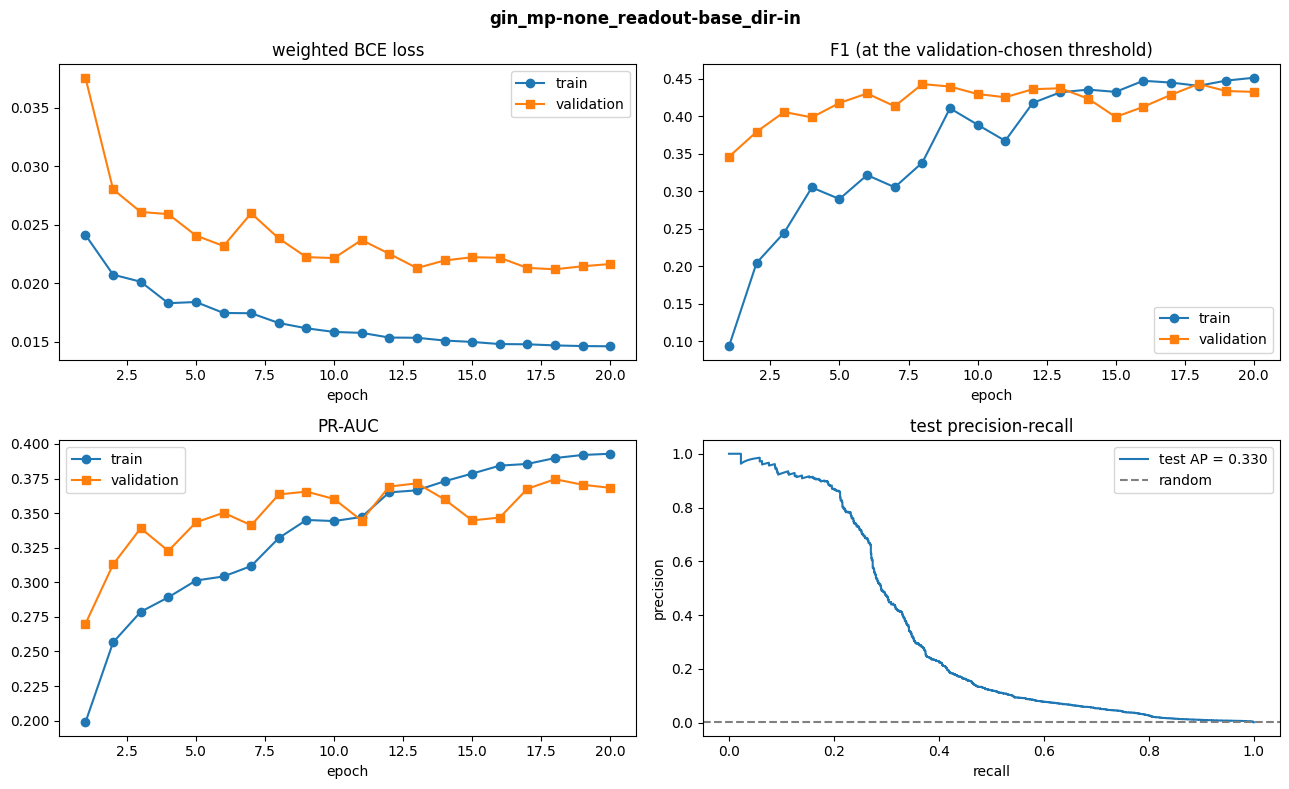

=== gin_mp-base_readout-base_dir-in ===
MP edge features: 20 | readout edge features: 20
total params: 108,419 | architecture-invariant: 67,587


/usr/local/lib/python3.12/dist-packages/torch_geometric/loader/link_neighbor_loader.py:252: UserWarning: Using 'NeighborSampler' without a 'pyg-lib' installation is deprecated and will be removed soon. Please install 'pyg-lib' for accelerated neighborhood sampling
  neighbor_sampler = NeighborSampler(


train:   0%|          | 0/372 [00:00<?, ?it/s]

predict train:   0%|          | 0/372 [00:00<?, ?it/s]

predict val:   0%|          | 0/124 [00:00<?, ?it/s]

...

epoch 20 | loss 0.0114 / 0.0208 | F1 0.5669 / 0.5625 @ 0.576 | PR-AUC 0.5319 / 0.4875 | 69s | RAM 7.8GB   (train / val)
best validation F1 0.5734 at epoch 17 (threshold 0.538)


predict train:   0%|          | 0/372 [00:00<?, ?it/s]

predict val:   0%|          | 0/124 [00:00<?, ?it/s]

predict test:   0%|          | 0/124 [00:00<?, ?it/s]

            train  validation    test
f1         0.5534      0.5734  0.4721
precision  0.6561      0.8537  0.6902
recall     0.4785      0.4316  0.3587
pr_auc     0.5267      0.4939  0.4180
roc_auc    0.9895      0.9742  0.9688
threshold  0.5378      0.5378  0.5378


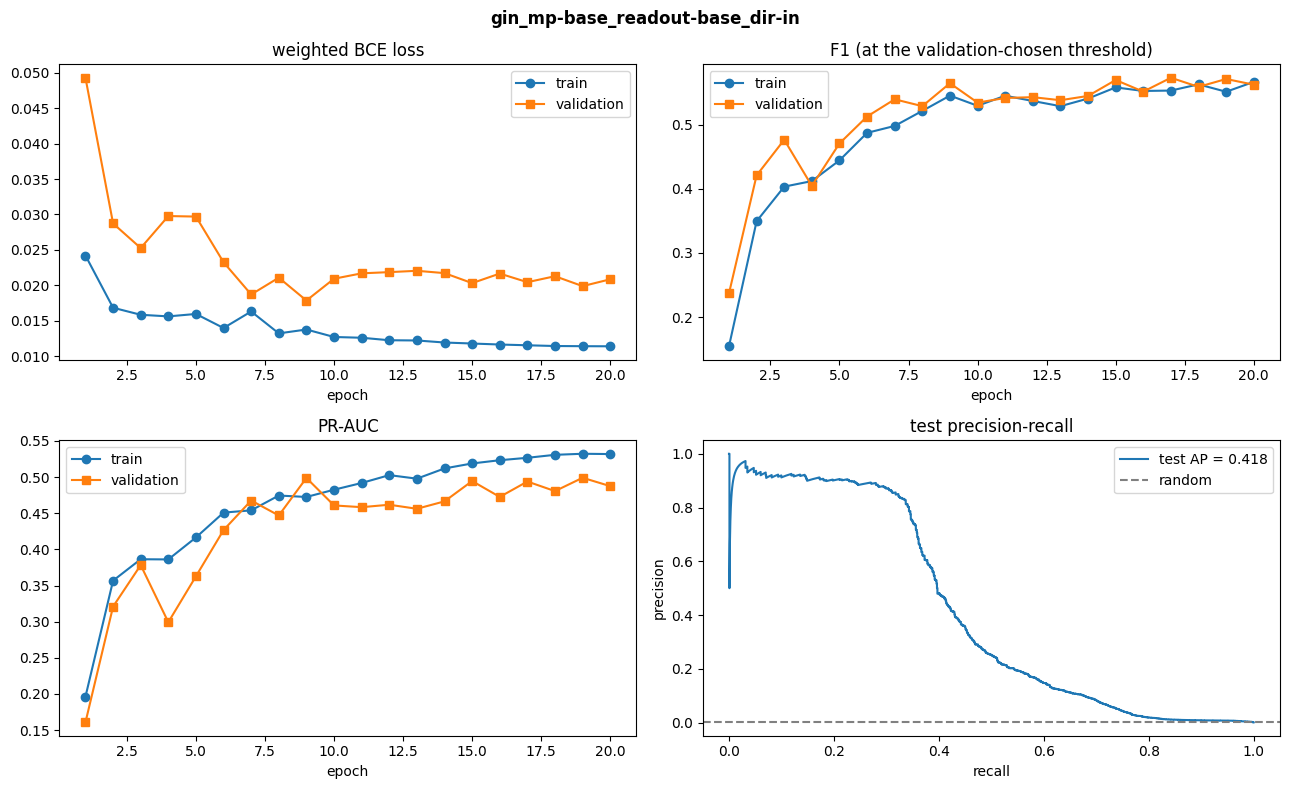

=== gin_mp-none_readout-full_dir-in ===
MP edge features: 0 | readout edge features: 81
total params: 110,851 | architecture-invariant: 67,587


/usr/local/lib/python3.12/dist-packages/torch_geometric/loader/link_neighbor_loader.py:252: UserWarning: Using 'NeighborSampler' without a 'pyg-lib' installation is deprecated and will be removed soon. Please install 'pyg-lib' for accelerated neighborhood sampling
  neighbor_sampler = NeighborSampler(


train:   0%|          | 0/372 [00:00<?, ?it/s]

predict train:   0%|          | 0/372 [00:00<?, ?it/s]

predict val:   0%|          | 0/124 [00:00<?, ?it/s]

...

epoch 20 | loss 0.0136 / 0.0195 | F1 0.4794 / 0.5334 @ 0.546 | PR-AUC 0.4370 / 0.4773 | 48s | RAM 8.0GB   (train / val)
best validation F1 0.5432 at epoch 11 (threshold 0.484)


predict train:   0%|          | 0/372 [00:00<?, ?it/s]

predict val:   0%|          | 0/124 [00:00<?, ?it/s]

predict test:   0%|          | 0/124 [00:00<?, ?it/s]

            train  validation    test
f1         0.4489      0.5444  0.4634
precision  0.5263      0.7480  0.5761
recall     0.3914      0.4279  0.3876
pr_auc     0.4135      0.4835  0.4322
roc_auc    0.9846      0.9812  0.9796
threshold  0.4841      0.4841  0.4841


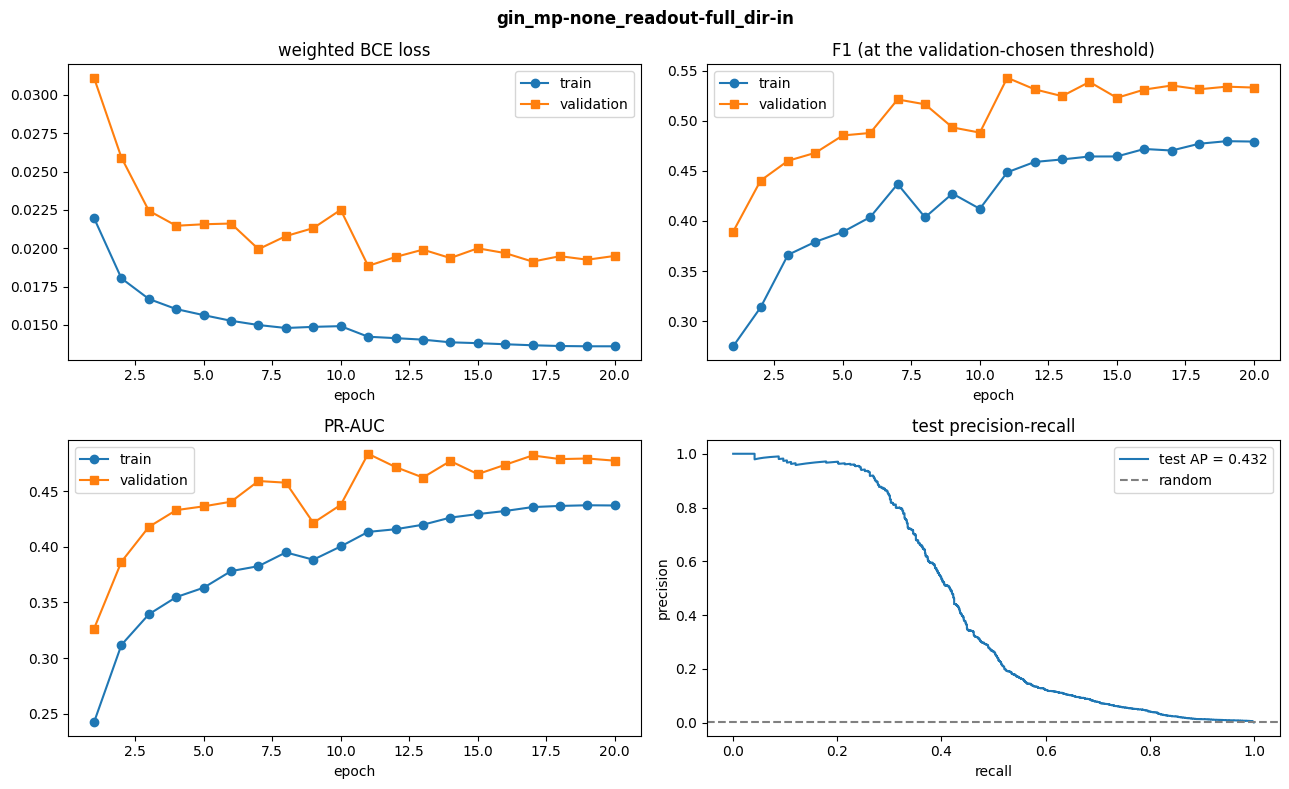

=== gin_mp-base_readout-full_dir-in ===
MP edge features: 20 | readout edge features: 81
total params: 116,227 | architecture-invariant: 67,587


/usr/local/lib/python3.12/dist-packages/torch_geometric/loader/link_neighbor_loader.py:252: UserWarning: Using 'NeighborSampler' without a 'pyg-lib' installation is deprecated and will be removed soon. Please install 'pyg-lib' for accelerated neighborhood sampling
  neighbor_sampler = NeighborSampler(


train:   0%|          | 0/372 [00:00<?, ?it/s]

predict train:   0%|          | 0/372 [00:00<?, ?it/s]

predict val:   0%|          | 0/124 [00:00<?, ?it/s]

...

epoch 20 | loss 0.0109 / 0.0190 | F1 0.5806 / 0.5958 @ 0.614 | PR-AUC 0.5473 / 0.5351 | 70s | RAM 9.1GB   (train / val)
best validation F1 0.6088 at epoch 8 (threshold 0.617)


predict train:   0%|          | 0/372 [00:00<?, ?it/s]

predict val:   0%|          | 0/124 [00:00<?, ?it/s]

predict test:   0%|          | 0/124 [00:00<?, ?it/s]

            train  validation    test
f1         0.5459      0.6088  0.5309
precision  0.7367      0.8418  0.7091
recall     0.4336      0.4769  0.4243
pr_auc     0.4858      0.5495  0.4887
roc_auc    0.9860      0.9829  0.9809
threshold  0.6168      0.6168  0.6168


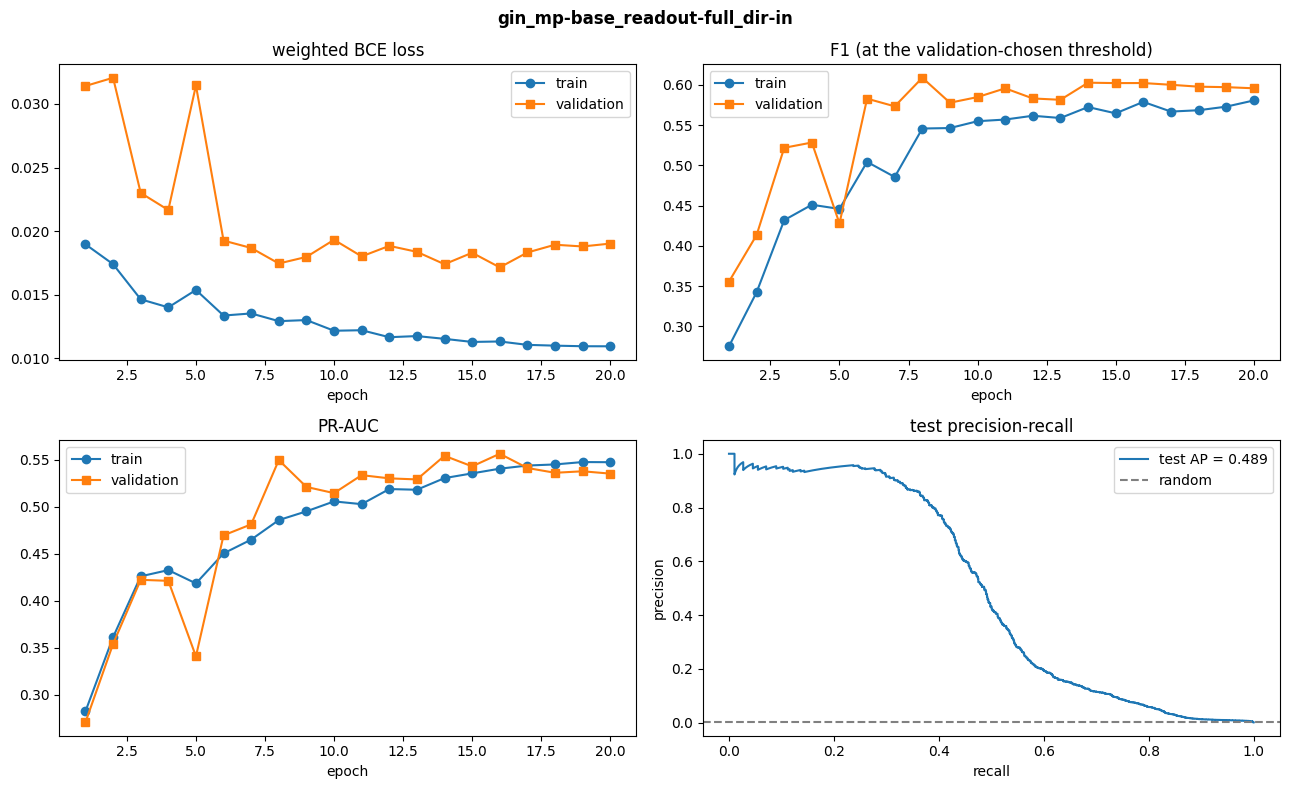

=== gin_mp-full_readout-full_dir-in ===
MP edge features: 81 | readout edge features: 81
total params: 131,843 | architecture-invariant: 67,587


/usr/local/lib/python3.12/dist-packages/torch_geometric/loader/link_neighbor_loader.py:252: UserWarning: Using 'NeighborSampler' without a 'pyg-lib' installation is deprecated and will be removed soon. Please install 'pyg-lib' for accelerated neighborhood sampling
  neighbor_sampler = NeighborSampler(


train:   0%|          | 0/372 [00:00<?, ?it/s]

predict train:   0%|          | 0/372 [00:00<?, ?it/s]

predict val:   0%|          | 0/124 [00:00<?, ?it/s]

...

epoch 20 | loss 0.0088 / 0.0252 | F1 0.6092 / 0.5653 @ 0.713 | PR-AUC 0.6199 / 0.4995 | 133s | RAM 11.9GB   (train / val)
best validation F1 0.6068 at epoch 10 (threshold 0.722)


predict train:   0%|          | 0/372 [00:00<?, ?it/s]

predict val:   0%|          | 0/124 [00:00<?, ?it/s]

predict test:   0%|          | 0/124 [00:00<?, ?it/s]

            train  validation    test
f1         0.5755      0.6068  0.5296
precision  0.8132      0.8834  0.8202
recall     0.4454      0.4621  0.3911
pr_auc     0.5436      0.5554  0.4922
roc_auc    0.9906      0.9795  0.9725
threshold  0.7219      0.7219  0.7219


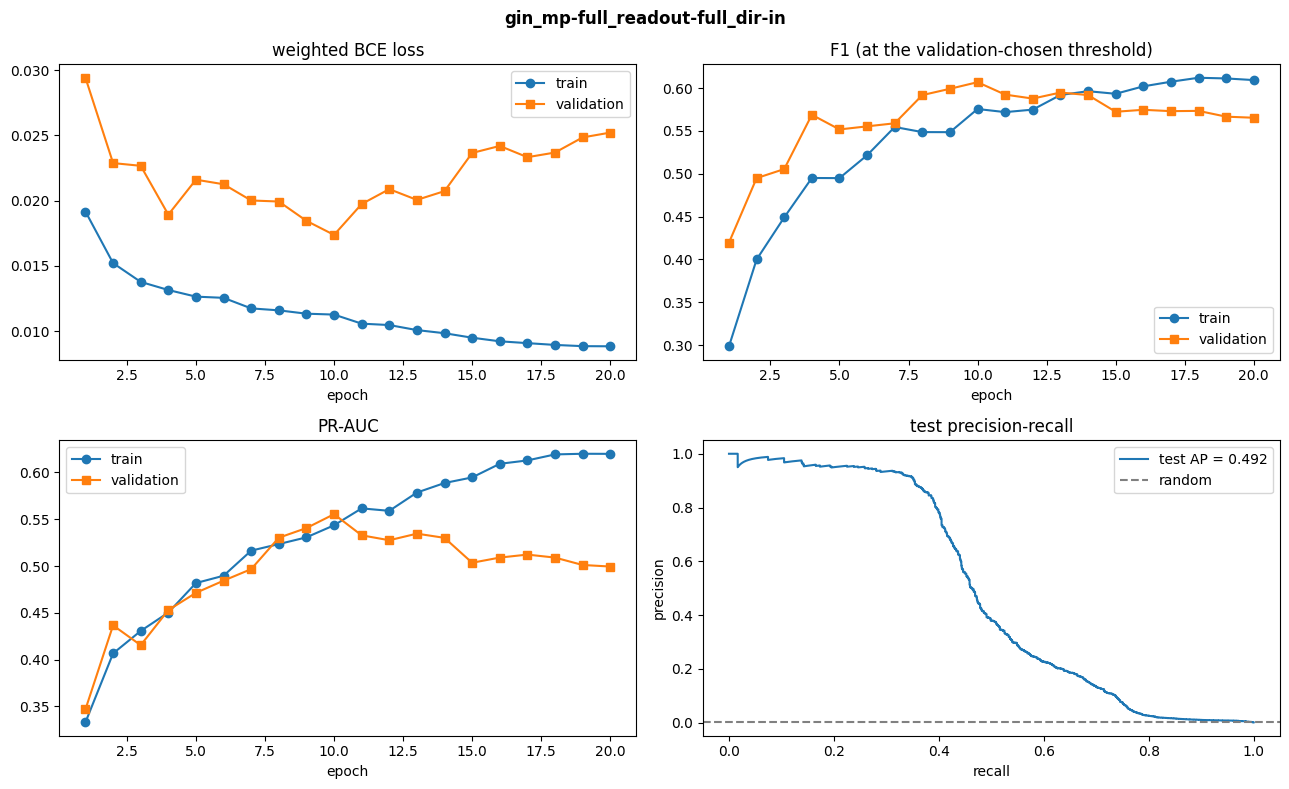

batch complete


In [9]:
all_results = []
for cfg in CONFIGS:
    print('=' * 90)
    all_results.append(run_experiment(**cfg))
print('=' * 90)
print('batch complete')

## 7. Comparison across the batch

All runs share the same architecture — `invariant_params` must be identical in every row.

In [10]:
summary = pd.DataFrame(all_results)
summary.to_csv(f'{OUT_ROOT}/batch_summary.csv', index=False)
summary.round(4)

,run,mp,readout,best_epoch,val_f1,test_f1,test_precision,test_recall,test_pr_auc,test_roc_auc,params,invariant_params
0,gin_mp-none_readout-base_dir-in,none,base,18,0.4426,0.3664,0.4414,0.3132,0.3301,0.9735,103043,67587
1,gin_mp-base_readout-base_dir-in,base,base,17,0.5734,0.4721,0.6902,0.3587,0.4180,0.9688,108419,67587
2,gin_mp-none_readout-full_dir-in,none,full,11,0.5444,0.4634,0.5761,0.3876,0.4322,0.9796,110851,67587
3,gin_mp-base_readout-full_dir-in,base,full,8,0.6088,0.5309,0.7091,0.4243,0.4887,0.9809,116227,67587
4,gin_mp-full_readout-full_dir-in,full,full,10,0.6068,0.5296,0.8202,0.3911,0.4922,0.9725,131843,67587


In [11]:
import shutil
shutil.make_archive('/kaggle/working/outputs_gin_baseline_191026', 'zip', '/kaggle/working/outputs')

'/kaggle/working/outputs_gin_baseline_191026.zip'